<table>
<tr>    
<td style="text-align: center">
<h1>Introduction to Sequential Data Processing and Sequential Models for ECG data</h1>
<h2><a href="http://home.agh.edu.pl/~horzyk/index.php">Adrian Horzyk</a></h2>
</td> 
<td>
<img src="http://home.agh.edu.pl/~horzyk/im/AdrianHorzyk49BT140h.png" alt="Adrian Horzyk, Professor" title="Adrian Horzyk, Professor" />        
</td> 
</tr>
</table>
<h3><i>Welcome to the interactive lecture and exercises where you can check everything and experiment!</i></h3>

# 🩺 ECG Signal Classification with Sequential Models
This notebook replicates the approach from the previous NLP-based notebook but applies it to ECG biomedical signals using different sequential models (SimpleRNN, GRU, LSTM, Conv1D).

We'll:
- Load and preprocess ECG data (e.g., from the MIT-BIH dataset)
- Train and compare sequential models
- Visualize accuracy/loss
- Discuss results and model suitability.

# 1. Load and Prepare ECG Dataset

To visualize the ECG data, let's proceed with the following steps:

1. **Load the ECG5000 Dataset**: You have already loaded the dataset using `fetch_openml`.

2. **Preprocess the Data**: The data has been normalized and reshaped into the correct format for training the model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml

# Load the ECG5000 dataset
data = fetch_openml('ECG5000', version=1, as_frame=False)
X = data['data']
y = data['target'].astype(int)

# Normalize and reshape the ECG data
X = X / np.max(np.abs(X))  # Normalize the ECG signals
X = X.reshape(-1, X.shape[1], 1)  # Reshape data to match model input shape (samples, time steps, channels)

# One-hot encode the labels
y = to_categorical(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Assuming the input data X_train has shape (num_samples, time_steps, features)
# and y_train is the one-hot encoded target labels with shape (num_samples, num_classes)
input_shape = X_train.shape[1:]  # (time_steps, features)
num_classes = y_train.shape[1]  # Number of classes

2025-04-13 22:34:23.983675: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-13 22:34:23.986910: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-13 22:34:23.994845: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744576464.007800 2592419 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744576464.011726 2592419 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744576464.022638 2592419 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

# 2. Visualize ECG Dataset

To visualize the ECG data, let's proceed with the following steps:

**Plot the ECG Signals**: We will plot a few sample ECG signals from the dataset.

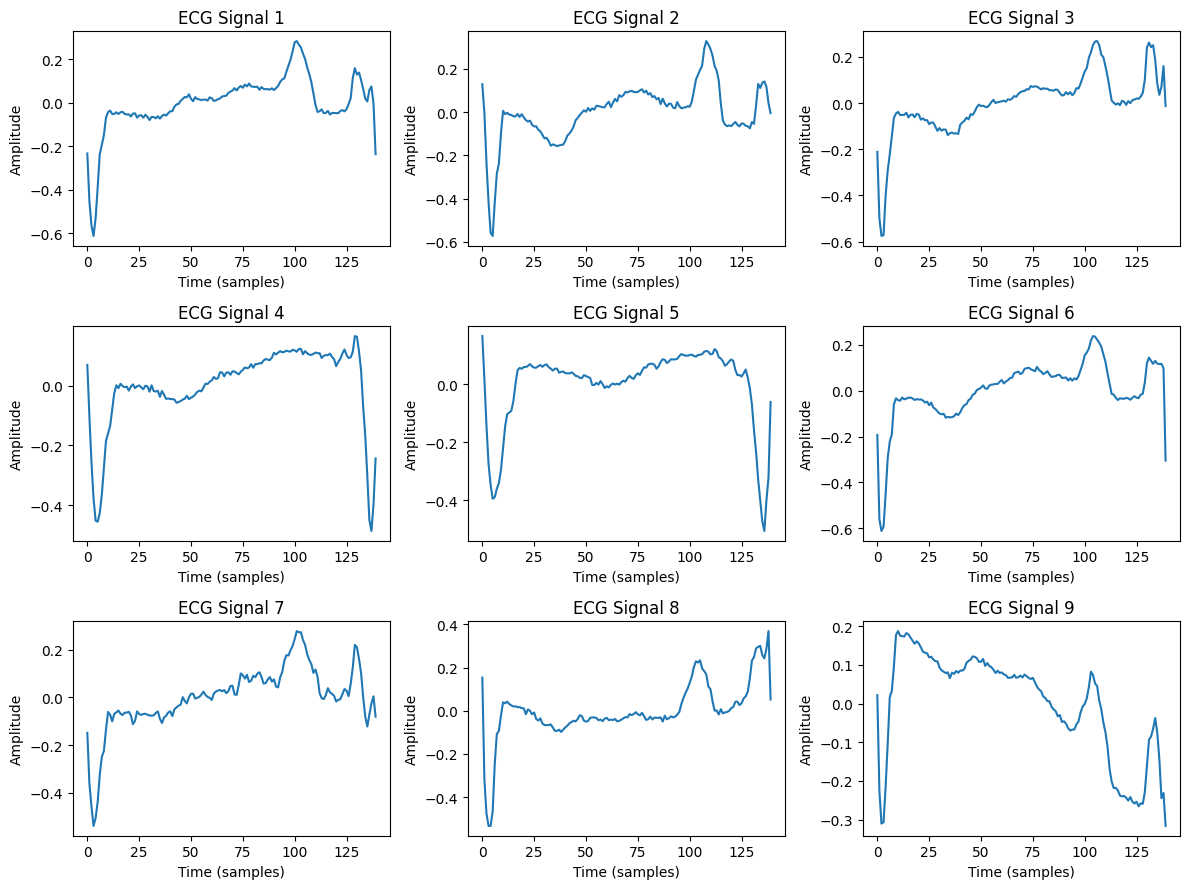

In [2]:
# Visualize the first few samples of the ECG data
plt.figure(figsize=(12, 9))

for i in range(9):  # Display the first 9 ECG signals
    plt.subplot(3, 3, i+1)
    plt.plot(X_train[i])
    plt.title(f"ECG Signal {i+1}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# 3. Define a Reusable Training Function

In [3]:
def train_model(model, name, X, y, epochs=20):
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(X, y, epochs=epochs, batch_size=32, verbose=0)
    acc_list = history.history["accuracy"]
    loss_list = history.history["loss"]
    print(f"✅ {name}: Final accuracy = {acc_list[-1]:.2f}")
    return acc_list, loss_list

# 4. Model A: SimpleRNN

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model_rnn = Sequential([
    SimpleRNN(16, input_shape=X_train.shape[1:]),
    Dense(y_train.shape[1], activation='softmax')
])

# Print the model summary to verify
model_rnn.summary()

# Train the model
rnn_acc, rnn_loss = train_model(model_rnn, "SimpleRNN", X_train, y_train)

E0000 00:00:1744576466.203032 2592419 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1744576466.213335 2592419 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/ahorzyk/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322 (1.26 KB)

 Trainable params: 322 (1.26 KB)

 Non-trainable params: 0 (0.00 B)

✅ SimpleRNN: Final accuracy = 0.98


# 5. Model B: GRU

In [5]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    GRU(16, input_shape=X_train.shape[1:]),
    Dense(y_train.shape[1], activation='softmax')
])

# Print the model summary to verify
model_gru.summary()

# Train the model
gru_acc, gru_loss = train_model(model_gru, "GRU", X_train, y_train)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 16)             │           912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 946 (3.70 KB)

 Trainable params: 946 (3.70 KB)

 Non-trainable params: 0 (0.00 B)

✅ GRU: Final accuracy = 0.97


# 6. Model C: LSTM

In [6]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    LSTM(16, input_shape=X_train.shape[1:]),
    Dense(y_train.shape[1], activation='softmax')
])

# Print the model summary to verify
model_lstm.summary()

# Train the model
lstm_acc, lstm_loss = train_model(model_lstm, "LSTM", X_train, y_train)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,186 (4.63 KB)

 Trainable params: 1,186 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

✅ LSTM: Final accuracy = 0.99


# 7. Model D: Conv1D

In [7]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

model_conv = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=X_train.shape[1:]),
    GlobalMaxPooling1D(),
    Dense(y_train.shape[1], activation='softmax')
])

# Print the model summary to verify
model_conv.summary()

# Train the model
conv_acc, conv_loss = train_model(model_conv, "Conv1D", X_train, y_train)

/home/ahorzyk/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 138, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194 (776.00 B)

 Trainable params: 194 (776.00 B)

 Non-trainable params: 0 (0.00 B)

✅ Conv1D: Final accuracy = 0.95


# 8. Model E: Conv1D + LSTM

In [8]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D
from tensorflow.keras.layers import LSTM

model_convlstm = Sequential([
    Conv1D(32, 9, activation='relu', input_shape=X_train.shape[1:]),
    LSTM(16, input_shape=X_train.shape[1:]),
    Dense(y_train.shape[1], activation='softmax')
])

# Print the model summary to verify
model_convlstm.summary()

# Train the model
convlstm_acc, convlstm_loss = train_model(model_convlstm, "Conv1D+LSTM", X_train, y_train)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 132, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,490 (13.63 KB)

 Trainable params: 3,490 (13.63 KB)

 Non-trainable params: 0 (0.00 B)

✅ Conv1D+LSTM: Final accuracy = 0.99


# 9. Model F: BiLSTM

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional, Dense, Dropout

# Assuming the input data X_train has shape (num_samples, time_steps, features)
# and y_train is the one-hot encoded target labels with shape (num_samples, num_classes)
input_shape = X_train.shape[1:]  # (time_steps, features)
num_classes = y_train.shape[1]  # Number of classes

# Build the BiLSTM model
bilstm_model = Sequential([
    # BiLSTM layer with input shape specified in the first layer
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.2), input_shape=input_shape),
    Bidirectional(LSTM(64, dropout=0.2)),
    # Output layer
    Dense(num_classes, activation='softmax')
])

# Print the model summary to verify
bilstm_model.summary()

# Train the model
bilstm_acc, bilstm_loss = train_model(bilstm_model, "BiLSTM", X_train, y_train)

/home/ahorzyk/.local/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 140, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,866 (519.01 KB)

 Trainable params: 132,866 (519.01 KB)

 Non-trainable params: 0 (0.00 B)

✅ BiLSTM: Final accuracy = 0.97


# 10. Model G: CNN-LSTM

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, LSTM, Dense, Dropout, Reshape

# Assuming the input data X_train has shape (num_samples, time_steps, features)
# and y_train is the one-hot encoded target labels with shape (num_samples, num_classes)
input_shape = X_train.shape[1:]  # (time_steps, features)
num_classes = y_train.shape[1]  # Number of classes

# Build the CNN-LSTM model
convlstm_model = Sequential([
    # CNN layer for feature extraction
    Conv1D(64, 9, activation='relu', input_shape=input_shape),
    GlobalMaxPooling1D(),  # Pooling layer to reduce dimensionality after convolution
    # Reshape the output from 2D to 3D for LSTM compatibility
    Reshape((1, 64)),  # Reshaping to (batch_size, time_steps=1, features=64)
    # LSTM layer for sequential dependencies
    LSTM(64, dropout=0.2),
    # Output layer
    Dense(num_classes, activation='softmax')
])

# Print the model summary to verify
convlstm_model.summary()

# Train the model
convlstm_acc, convlstm_loss = train_model(convlstm_model, "CNN-LSTM", X_train, y_train)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 132, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,794 (132.01 KB)

 Trainable params: 33,794 (132.01 KB)

 Non-trainable params: 0 (0.00 B)

✅ CNN-LSTM: Final accuracy = 0.98


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, LSTM, Dense, Dropout, Reshape
from tensorflow.keras.layers import LeakyReLU, ELU

# Assuming the input data X_train has shape (num_samples, time_steps, features)
# and y_train is the one-hot encoded target labels with shape (num_samples, num_classes)
input_shape = X_train.shape[1:]  # (time_steps, features)
num_classes = y_train.shape[1]  # Number of classes

# Build the CNN-LSTM model
convlstm_model = Sequential([
    # CNN layer for feature extraction
    Conv1D(64, 9, activation='elu', input_shape=input_shape),
    GlobalMaxPooling1D(),  # Pooling layer to reduce dimensionality after convolution
    # Reshape the output from 2D to 3D for LSTM compatibility
    Reshape((1, 64)),  # Reshaping to (batch_size, time_steps=1, features=64)
    # LSTM layer for sequential dependencies
    LSTM(64, dropout=0.2),
    # Output layer
    Dense(num_classes, activation='softmax')
])

# Print the model summary to verify
convlstm_model.summary()

# Train the model
convlstm_acc, convlstm_loss = train_model(convlstm_model, "CNN-LSTM", X_train, y_train)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 132, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,794 (132.01 KB)

 Trainable params: 33,794 (132.01 KB)

 Non-trainable params: 0 (0.00 B)

✅ CNN-LSTM: Final accuracy = 0.98


# 11. Visualize Accuracy and Loss per Epoch

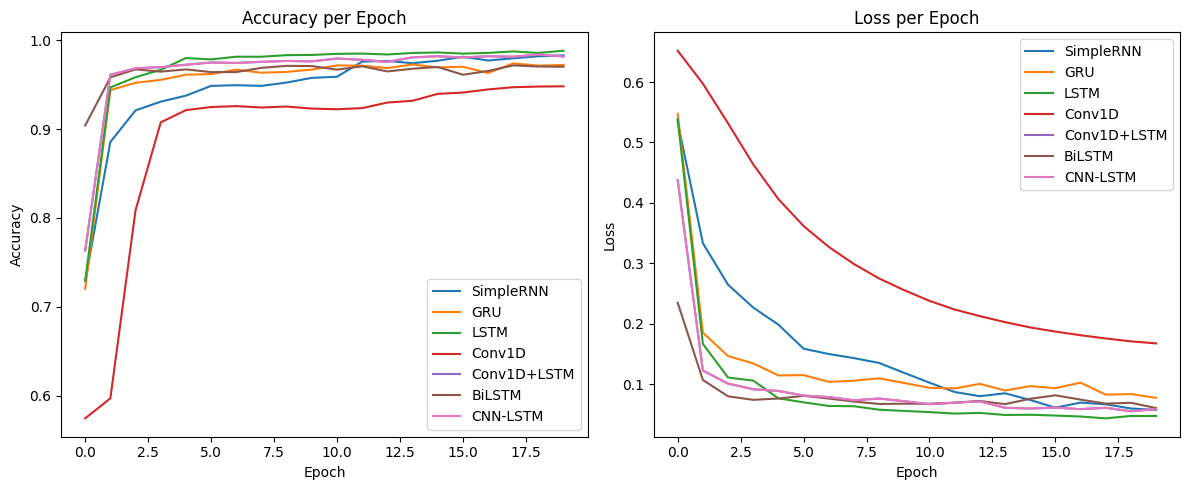

In [12]:
import matplotlib.pyplot as plt

models = ["SimpleRNN", "GRU", "LSTM", "Conv1D", "Conv1D+LSTM", "BiLSTM", "CNN-LSTM"]
accuracies = [rnn_acc, gru_acc, lstm_acc, conv_acc, convlstm_acc, bilstm_acc, convlstm_acc]
losses = [rnn_loss, gru_loss, lstm_loss, conv_loss, convlstm_loss, bilstm_loss, convlstm_loss]

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
for acc, name in zip(accuracies, models):
    plt.plot(acc, label=name)
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
for loss, name in zip(losses, models):
    plt.plot(loss, label=name)
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Summary and Assignments

This comparison shows how fast and how well the presented models learn. 

Try to use a larger dataset and achieve good results.